# Working with text

From the text analysis lesson (notes shared as a PDF) and its three colabs: text representation,
text classification with logistic regression, and combining text with numeric features.

1. text as data, and turning it into vectors
2. bag of words with `CountVectorizer`: lowercasing, tokens, stop words, n-grams
3. TF-IDF, worked out by hand
4. classifying SMS messages as spam with TF-IDF + logistic regression
5. 20 newsgroups, and what a model learns when you don't look
6. text and numeric features together with `ColumnTransformer`

## Text as data

Text is everywhere: web pages, emails, social media, reviews, comments, medical reports, research papers,
news. It's **unstructured** data, like images, audio and video, as opposed to **structured** (tabular)
data with a fixed set of columns.

ML algorithms need numeric vectors, so every kind of unstructured data needs a conversion step:

* text → vectors (natural language processing)
* images → vectors (computer vision); video is a sequence of images
* audio → vectors (speech processing)

So the workflow is: text → representation → ML model → output.

Common tasks, almost all of them classification:

* **sentiment analysis**: is a review positive, negative or neutral?
* **spam filtering**: spam or not?
* **news classification**: politics, sport, entertainment...
* **entity / product feature extraction**: classify each *word* (is it a product attribute or not?)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', message='.*penalty.*')

## Bag of words

In [2]:
corpus = [
    'This is the first document',
    'This document is the second document',
    'And this is the third one.',
    'Is this the first document?',
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)
pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

,and,document,first,is,one,second,the,third,this
0,0,1,1,1,0,0,1,0,1
1,0,2,0,1,0,1,1,0,1
2,1,0,0,1,1,0,1,1,1
3,0,1,1,1,0,0,1,0,1


Each document becomes a row of word counts over the whole vocabulary (9 words). Word order is thrown
away completely: "this is the first document" and "is this the first document" get identical vectors (rows
0 and 3). That's why it's called a **bag of words**.

`X` is a sparse matrix. With a real vocabulary of tens of thousands of words, almost every entry is 0, so
storing only the non-zeros saves a lot of memory.

### Options that change the vocabulary

Without lowercasing, "This" and "this" are different words:

In [3]:
vectorizer = CountVectorizer(lowercase=False)
X = vectorizer.fit_transform(corpus)
print(f'Number of features: {len(vectorizer.get_feature_names_out())}')
pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

Number of features: 11


,And,Is,This,document,first,is,one,second,the,third,this
0,0,0,1,1,1,1,0,0,1,0,0
1,0,0,1,2,0,1,0,1,1,0,0
2,1,0,0,0,0,1,1,0,1,1,1
3,0,1,0,1,1,0,0,0,1,0,1


`token_pattern` decides what counts as a word. The default `r"(?u)\b\w\w+\b"` keeps tokens of 2+
letters or digits (so single letters like "a" and "I" are dropped). `r'[a-zA-Z]+'` keeps only letters,
which drops numbers:

In [4]:
vectorizer = CountVectorizer(token_pattern=r'[a-zA-Z]+')
vectorizer.fit(corpus + ['Call 08452810075 now'])
vectorizer.get_feature_names_out()

array(['and', 'call', 'document', 'first', 'is', 'now', 'one', 'second',
       'the', 'third', 'this'], dtype=object)

### Stop words

Very common words ("the", "is", "and") appear everywhere and carry little meaning on their own.
`stop_words='english'` removes them using sklearn's built-in list:

In [5]:
vectorizer = CountVectorizer(token_pattern=r'[a-zA-Z]+', stop_words='english')
X = vectorizer.fit_transform(corpus)
print(f'Number of features: {len(vectorizer.get_feature_names_out())}')
pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

Number of features: 2


,document,second
0,1,0
1,2,1
2,0,0
3,1,0


Only two words survive. sklearn's list is aggressive: it includes "first", "third" and "one" as well as
the obvious ones. On real data, removing stop words can help or hurt, and it's worth testing both. For
sentiment, for example, the list includes "not" and "no", which flip the meaning of a sentence.

### N-grams

`ngram_range=(1, 2)` adds pairs of consecutive words as extra features, which brings back a little word
order ("not good" vs "good"):

In [6]:
vectorizer = CountVectorizer(ngram_range=(1, 2), token_pattern=r'[a-zA-Z]+')
X = vectorizer.fit_transform(corpus)
print(f'Number of features: {len(vectorizer.get_feature_names_out())}')
pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

Number of features: 22


,and,and this,document,document is,first,first document,is,is the,is this,one,...,the,the first,the second,the third,third,third one,this,this document,this is,this the
0,0,0,1,0,1,1,1,1,0,0,...,1,1,0,0,0,0,1,0,1,0
1,0,0,2,1,0,0,1,1,0,0,...,1,0,1,0,0,0,1,1,0,0
2,1,1,0,0,0,0,1,1,0,1,...,1,0,0,1,1,1,1,0,1,0
3,0,0,1,0,1,1,1,0,1,0,...,1,1,0,0,0,0,1,0,0,1


9 single words + 13 distinct word pairs = 22 features. The vocabulary grows quickly with n, which is why
`max_features` or `min_df` (drop words that appear in fewer than `min_df` documents) are often used to cap it.

(The comment in the course code said `ngram_range=(1,2)` means "only bi-grams". It means unigrams **and**
bigrams; `(2, 2)` would be only bigrams.)

## TF-IDF

Raw counts give frequent words a lot of weight regardless of how informative they are. TF-IDF multiplies
each count by the word's **inverse document frequency**, so words that appear in many documents count less:

$$\text{tfidf}(t, d) = \text{tf}(t, d) \times \text{idf}(t)$$

sklearn's idf, with $n$ documents and $\text{df}(t)$ = number of documents containing $t$:

* `smooth_idf=False`: $\text{idf}(t) = \ln\frac{n}{\text{df}(t)} + 1$
* `smooth_idf=True` (default): $\text{idf}(t) = \ln\frac{1 + n}{1 + \text{df}(t)} + 1$, as if one
  extra document contained every word once, which avoids division by zero

The +1 at the end means a word that appears in every document still gets weight 1, not 0. Then each row is
divided by its length (`norm='l2'`), so long and short documents are comparable.

### By hand

Document 0 is "This is the first document". In the 4-document corpus, "this", "is" and "the" appear in all
4, "document" in 3 and "first" in 2.

In [7]:
n = 4
df_counts = {'this': 4, 'is': 4, 'the': 4, 'first': 2, 'document': 3}

rows = []
for word, df_t in df_counts.items():
    rows.append({'word': word, 'df': df_t,
                 'idf (no smoothing)': np.log(n / df_t) + 1,
                 'idf (smoothed)': np.log((n + 1) / (df_t + 1)) + 1})
manual = pd.DataFrame(rows).set_index('word')
manual

,df,idf (no smoothing),idf (smoothed)
word,,,
this,4,1.000000,1.000000
is,4,1.000000,1.000000
the,4,1.000000,1.000000
first,2,1.693147,1.510826
document,3,1.287682,1.223144


Each word appears once in document 0 (tf = 1), so the raw tf-idf values are just the smoothed idfs.
Normalising that vector to length 1 should give exactly what `TfidfVectorizer` produces:

In [8]:
raw = manual['idf (smoothed)']
by_hand = raw / np.sqrt((raw ** 2).sum())

tfidf = TfidfVectorizer()          # smooth_idf=True, norm='l2' by default
X_tfidf = tfidf.fit_transform(corpus)
sk = pd.Series(X_tfidf.toarray()[0], index=tfidf.get_feature_names_out())

pd.DataFrame({'by hand': by_hand, 'sklearn': sk[by_hand.index]}).round(6)

,by hand,sklearn
word,,
this,0.384085,0.384085
is,0.384085,0.384085
the,0.384085,0.384085
first,0.580286,0.580286
document,0.469791,0.469791


In [9]:
pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out()).round(3)

,and,document,first,is,one,second,the,third,this
0,0.000,0.470,0.58,0.384,0.000,0.000,0.384,0.000,0.384
1,0.000,0.688,0.00,0.281,0.000,0.539,0.281,0.000,0.281
2,0.512,0.000,0.00,0.267,0.512,0.000,0.267,0.512,0.267
3,0.000,0.470,0.58,0.384,0.000,0.000,0.384,0.000,0.384


"first" gets the highest weight in documents 0 and 3 because it's the rarest word in them. "is", "the" and
"this" are in every document and get the lowest.

### The textbook formula

The large-scale learning colab used a different, also common definition: tf as a *proportion* of the
document's words, and $\text{idf} = \log_{10}\frac{n}{\text{df}}$ with no +1. For

* r1: "this is a a sample"
* r2: "this is another another example example example"

"this" is in both documents, so idf = log(2/2) = 0 and its tf-idf is 0. "example" appears 3 times in r2's 7
words: tf = 3/7 = 0.429, idf = log10(2/1) = 0.301, tf-idf = 0.129. (The original worked example used
log(3/2) for these, mixing in the +1 smoothing from a different formula, and got 0.0755.)

Different libraries use different variants; what matters is the idea, and knowing which one your tool uses
when comparing numbers.

## Spam classification

The SMS Spam Collection: 5,572 text messages labelled `ham` (legitimate) or `spam`. The text representation
colab downloaded it and stopped there; here it's used for the classification workflow from the logistic
regression colab.

In [10]:
import io, os, urllib.request, zipfile

if not os.path.exists('SMSSpamCollection'):
    url = 'https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip'
    with zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(url).read())) as z:
        z.extract('SMSSpamCollection')

sms = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['label', 'text'])
sms.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
print(sms.shape)
print(sms['label'].value_counts(normalize=True).round(3))

(5572, 2)
label
ham     0.866
spam    0.134
Name: proportion, dtype: float64


In [12]:
for label in ['ham', 'spam']:
    print(f"--- {label}")
    for t in sms.loc[sms.label == label, 'text'].sample(3, random_state=1):
        print(" ", t)

--- ham
  Ok enjoy . R u there in home.
  Yo, the game almost over? Want to go to walmart soon
  Shall i come to get pickle
--- spam
  Marvel Mobile Play the official Ultimate Spider-man game (£4.50) on ur mobile right now. Text SPIDER to 83338 for the game & we ll send u a FREE 8Ball wallpaper
  Thank you, winner notified by sms. Good Luck! No future marketing reply STOP to 84122 customer services 08450542832
  Free msg. Sorry, a service you ordered from 81303 could not be delivered as you do not have sufficient credit. Please top up to receive the service.


Only 13% spam, so accuracy alone would be misleading (always guessing "ham" gets 87%). Spam is easy to spot by
eye: prizes, "free", phone numbers, "txt".

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(sms['text'], sms['label'], test_size=0.3,
                                                    random_state=42, stratify=sms['label'])
print("train:", len(X_train), " test:", len(X_test))

train: 3900  test: 1672


### Pipeline: TF-IDF + logistic regression

Putting the vectoriser inside the pipeline matters: the vocabulary and idf values are learned from the
training messages only, and every cross validation fold refits them on its own training part.

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

logreg_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, stop_words='english', max_features=5000)),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42)),
])
logreg_pipeline.fit(X_train, y_train)
print(classification_report(y_test, logreg_pipeline.predict(X_test), digits=3))

              precision    recall  f1-score   support

         ham      0.961     1.000     0.980      1448
        spam      1.000     0.741     0.851       224

    accuracy                          0.965      1672
   macro avg      0.981     0.871     0.916      1672
weighted avg      0.967     0.965     0.963      1672



The model is

$$P(\text{spam} \mid \mathbf{x}) = \sigma(z) = \frac{1}{1 + e^{-z}}, \qquad z = b + w_1 x_1 + \dots + w_{5000} x_{5000}$$

where $x_j$ is the tf-idf value of word $j$ in the message. (The course notes wrote $\sigma(\frac{1}{1+e^{-z}})$,
which applies the sigmoid twice.)

Precision for spam is very high, but recall is lower: about 1 in 4 spam messages gets through. With the
default `C=1` the regularisation is fairly strong for this many features, and the imbalance pushes the
model towards "ham".

### Inspecting the model

Each word has one weight. Positive pushes towards spam, negative towards ham:

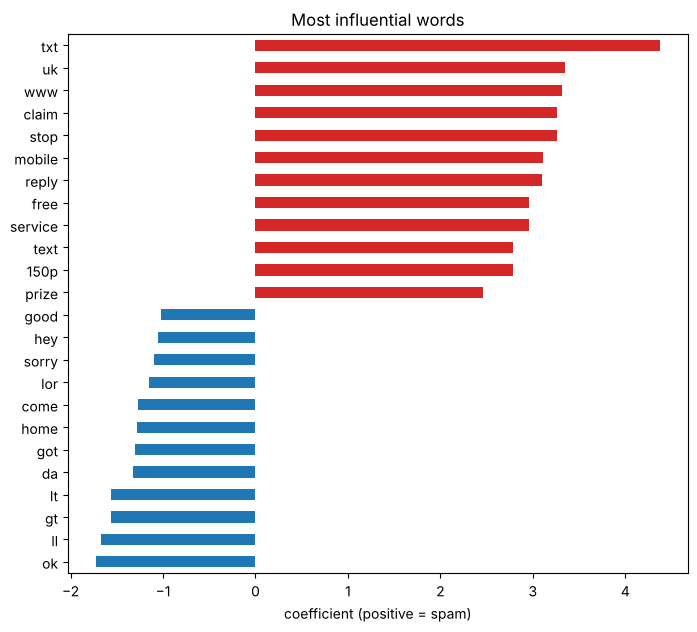

In [15]:
weights = pd.Series(logreg_pipeline.named_steps['logreg'].coef_[0],
                    index=logreg_pipeline.named_steps['tfidf'].get_feature_names_out())
top = pd.concat([weights.nlargest(12), weights.nsmallest(12)]).sort_values()

plt.figure(figsize=(8, 7))
top.plot.barh(color=['tab:blue' if w < 0 else 'tab:red' for w in top])
plt.xlabel('coefficient (positive = spam)')
plt.title('Most influential words')
plt.show()

Spam words are what you'd expect (txt, free, mobile, claim, reply, prize, www...). The ham side is dominated
by casual conversation words. Note that "ll", "gt" and "lt" show up: the default tokeniser splits "I'll" into
"ll", and `&lt;` / `&gt;` are HTML entities left in some messages.

### Tuning

The course tuned the n-gram range, `C` and the penalty type. Here `C` gets four values, so 2 x 4 x 2 = 16
combinations (80 fits with 5-fold CV). Scoring on F1 for the spam class instead of accuracy, since that's the class that matters:

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'logreg__C': [0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver': ['liblinear'],
}
grid_search = GridSearchCV(logreg_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, (y_train == 'spam').astype(int))
print(grid_search.best_params_, f" CV F1 {grid_search.best_score_:.3f}")

{'logreg__C': 100, 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear', 'tfidf__ngram_range': (1, 2)}  CV F1 0.941


              precision    recall  f1-score   support

         ham      0.984     0.997     0.990      1448
        spam      0.976     0.893     0.932       224

    accuracy                          0.983      1672
   macro avg      0.980     0.945     0.961      1672
weighted avg      0.983     0.983     0.982      1672



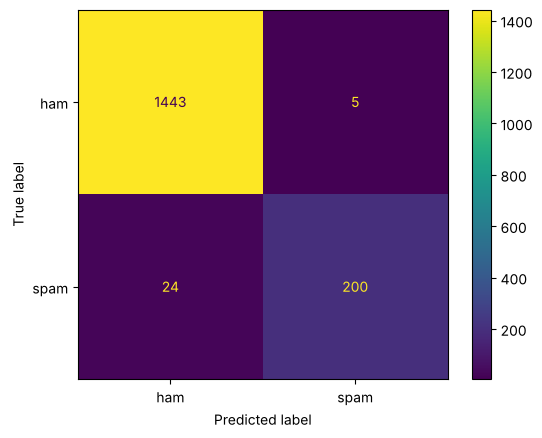

In [17]:
best = grid_search.best_estimator_
y_pred = np.where(best.predict(X_test) == 1, 'spam', 'ham')
print(classification_report(y_test, y_pred, digits=3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

A much larger `C` (weaker regularisation) brings spam recall up a lot while keeping precision high.

Trying it on new messages:

In [18]:
messages = ["Congratulations! You've won a free cruise. Call now to claim your prize",
            "Are we still meeting for lunch tomorrow?",
            "URGENT: your account has been selected, reply YES to receive cash",
            "Can you send me the notes from today's lecture"]
for m, p in zip(messages, best.predict_proba(messages)[:, 1]):
    print(f"{p:.3f}  {m}")

0.995  Congratulations! You've won a free cruise. Call now to claim your prize
0.000  Are we still meeting for lunch tomorrow?
0.987  URGENT: your account has been selected, reply YES to receive cash
0.015  Can you send me the notes from today's lecture


## 20 newsgroups: alt.atheism vs soc.religion.christian

The logistic regression colab used two newsgroups from 20 newsgroups. The outputs in this section are from
my Colab run (the download host isn't reachable from where I rebuilt these notebooks), but the result is
worth keeping because of what the model learned.

In [19]:
from sklearn.datasets import fetch_20newsgroups

newsgroups = fetch_20newsgroups(subset='all', categories=['alt.atheism', 'soc.religion.christian'])
X_ng, y_ng = newsgroups.data, newsgroups.target
target_names = newsgroups.target_names
target_names

['alt.atheism', 'soc.religion.christian']

In [20]:
Xn_train, Xn_test, yn_train, yn_test = train_test_split(X_ng, y_ng, test_size=0.3, random_state=42)
print("# examples in train:", len(Xn_train))
print("# examples in test:", len(Xn_test))

# examples in train: 1257
# examples in test: 539


In [21]:
ng_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, stop_words='english', max_features=5000)),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42)),
]).fit(Xn_train, yn_train)
print(classification_report(yn_test, ng_pipeline.predict(Xn_test), target_names=target_names))

Performance of logistic regression on two categories of 20newsgroup dataset
                        precision    recall  f1-score   support

           alt.atheism       0.99      0.94      0.96       235
soc.religion.christian       0.96      0.99      0.97       304

              accuracy                           0.97       539
             macro avg       0.97      0.97      0.97       539
          weighted avg       0.97      0.97      0.97       539



97% accuracy. But the most important words:

In [22]:
feature_weights = ng_pipeline.named_steps['logreg'].coef_[0]
feature_names = ng_pipeline.named_steps['tfidf'].get_feature_names_out()
for feature, weight in sorted(zip(feature_names, feature_weights), key=lambda x: abs(x[1]), reverse=True)[:20]:
    print(feature, weight)

nntp -2.202472569343568
host -2.1728056770861612
posting -2.1558466639601757
keith -2.11774165492962
rutgers 2.100736929249545
christians 1.9426605687212914
church 1.8828453093824011
atheism -1.8525470368454087
christ 1.7425000874850651
athos 1.64641232674509
sin 1.6371890515354857
edu -1.5340441733150116
mathew -1.5187656866004917
1993 1.5041461274903705
atheists -1.4592148245116614
morality -1.3787667945994209
christian 1.3667221800176443
sandvik -1.3205644098971838
caltech -1.275274387334199
cs -1.23367829706225


The top four are **nntp**, **host**, **posting** and **keith**. "NNTP-Posting-Host" is an email header line,
and "keith", "mathew", "sandvik" are names of individual frequent posters; "rutgers", "caltech", "edu", "cs"
are university email domains. Of the top 20, only a handful ("christians", "church", "atheism", "christ",
"sin", "morality") are about the actual topic.

So a good part of the 97% comes from recognising *who* posted and *how their mail software formatted the
header*, which wouldn't carry over to new posts from new people. This is a classic example of a model
taking a shortcut. `fetch_20newsgroups(..., remove=('headers', 'footers', 'quotes'))` strips that metadata
and gives a much more honest (and lower) score. Looking at the learned weights is how you catch this.

The grid search from the course (n-grams, `C`, penalty) picked `C=10`, L2 and unigrams + bigrams, with the
same 97% on the test set:

In [23]:
grid_search_ng = GridSearchCV(ng_pipeline, {'tfidf__ngram_range': [(1, 1), (1, 2)], 'logreg__C': [0.1, 1, 10],
                                            'logreg__penalty': ['l1', 'l2'], 'logreg__solver': ['liblinear']},
                              cv=5, n_jobs=-1).fit(Xn_train, yn_train)
print(grid_search_ng.best_params_)

{'logreg__C': 10, 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear', 'tfidf__ngram_range': (1, 2)}


## Text and numbers together

Real data often mixes free text with numeric and categorical columns, for example a product review with a
price and a popularity score. `ColumnTransformer` can send each column through its own preprocessing.

Synthetic data from the lesson: 500 product reviews in four categories. Each review is made of random words
from a category-specific word list, the rating depends on the category, and price and popularity are pure noise.

In [24]:
rng = np.random.RandomState(42)
n_samples = 500

price = rng.uniform(10, 100, n_samples)
popularity = rng.randint(0, 1000, n_samples)

categories = ['electronics', 'clothing', 'books', 'home_decor']
category_options = rng.choice(categories, n_samples)

keywords = {
    'electronics': ['device', 'battery', 'screen', 'performance', 'camera', 'sound', 'quality', 'fast', 'recommend', 'great'],
    'clothing': ['fabric', 'fit', 'size', 'comfortable', 'style', 'color', 'soft', 'wear', 'love', 'perfect'],
    'books': ['story', 'characters', 'plot', 'reading', 'author', 'recommend', 'enjoyed', 'interesting', 'page', 'written'],
    'home_decor': ['decor', 'design', 'style', 'room', 'color', 'beautiful', 'quality', 'look', 'home', 'recommend'],
}
rating_params = {'electronics': (4.0, 0.8), 'clothing': (3.5, 1.0), 'books': (4.2, 0.7), 'home_decor': (3.8, 0.9)}

review_text = [' '.join(rng.choice(keywords[c], rng.randint(10, 30))) for c in category_options]
ratings = np.clip([rng.normal(*rating_params[c]) for c in category_options], 1, 5).round(1)

data = pd.DataFrame({'review_text': review_text, 'price': price, 'popularity': popularity,
                     'category': category_options, 'rating': ratings})
data.head()

,review_text,price,popularity,category,rating
0,quality color beautiful beautiful look home de...,43.708611,501,home_decor,3.7
1,reading enjoyed plot characters written enjoye...,95.564288,958,books,5.0
2,written characters enjoyed characters plot enj...,75.879455,144,books,3.8
3,recommend quality performance camera device de...,63.879264,200,electronics,4.9
4,great camera camera sound quality fast fast ba...,24.041678,928,electronics,4.0


(The lesson's generator used the global `np.random.seed(42)` and a chain of `if/elif` blocks; a local
`RandomState` and two dictionaries do the same thing.)

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

numerical_features = ['price', 'popularity']
text_feature = 'review_text'

X = data[numerical_features + [text_feature]]
y = data['rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocess = ColumnTransformer([
    ('scaler', StandardScaler(), numerical_features),
    ('bow', CountVectorizer(stop_words='english', max_features=5000), text_feature),
])
regression_pipeline = Pipeline([('preprocess', preprocess),
                                ('regressor', RandomForestRegressor(random_state=42))])
regression_pipeline.fit(X_train, y_train)
print(f"test MSE: {mean_squared_error(y_test, regression_pipeline.predict(X_test)):.3f}")

test MSE: 0.766


Note the text column is given as a plain string (`'review_text'`), not a list. `CountVectorizer` expects a 1D
sequence of documents; with `['review_text']` it would get a 2D column and fail.

Is 0.77 any good? Comparing against a baseline and against each part on its own:

In [26]:
def mse_of(transformers):
    pipe = Pipeline([('preprocess', ColumnTransformer(transformers)),
                     ('regressor', RandomForestRegressor(random_state=42))]).fit(X_train, y_train)
    return mean_squared_error(y_test, pipe.predict(X_test))

results = {
    'predict the mean': mean_squared_error(y_test, DummyRegressor().fit(X_train, y_train).predict(X_test)),
    'numbers only': mse_of([('scaler', StandardScaler(), numerical_features)]),
    'text only': mse_of([('bow', CountVectorizer(stop_words='english'), text_feature)]),
    'numbers + text': mse_of([('scaler', StandardScaler(), numerical_features),
                              ('bow', CountVectorizer(stop_words='english'), text_feature)]),
}
pd.Series(results, name='test MSE').round(3)

predict the mean    0.751
numbers only        0.874
text only           0.739
numbers + text      0.766
Name: test MSE, dtype: float64

* Price and popularity alone are worse than predicting the mean: they're random noise, and the forest fits
  that noise.
* The text alone is only slightly better than the baseline. It helps at all because the words reveal the category, and the category
  shifts the average rating.
* Adding the noisy numeric columns to the text makes it slightly worse.

Even the best model can't do much: within a category the rating is random (standard deviation 0.7-1.0, so
an MSE around 0.7 is roughly the floor). Knowing the category is all the text can tell you here.

## Summary

* text has to be turned into vectors first: bag of words (`CountVectorizer`) or TF-IDF (`TfidfVectorizer`)
* lowercasing, the token pattern, stop words, n-grams and `max_features` / `min_df` all change the vocabulary
* keep the vectoriser inside the pipeline so it's fitted on training data only
* logistic regression on TF-IDF is a strong, fast, interpretable baseline for text classification
* always look at the top-weighted words. They show what the model actually learned, which may be headers and
  usernames rather than the topic
* `ColumnTransformer` combines text with other feature types in one model